# 08 — Random Forest
Walk-forward Random Forest on weekly silver log-returns with lagged features.
Same train/val/test split and evaluation metrics as the ARIMA, LSTM, and XGBoost notebooks.

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from itertools import product
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

## 1. Load features

In [190]:
train = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

TARGET       = 'silver_return'
EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return', 'sp500_return',
                'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level features — separate group for ablation (see §8)
EXOG         = EXOG_RETURNS + EXOG_LEVELS

# Returns are additive across days → use sum to get the weekly log-return.
# Levels (z-scores, ratios) are point-in-time → use .last() for the Friday close.
agg = {TARGET: 'sum'}
for c in EXOG_RETURNS:
    agg[c] = 'sum'
for c in EXOG_LEVELS:
    agg[c] = 'last'

def to_weekly(df):
    cols = [c for c in agg.keys() if c in df.columns]
    return df[cols].resample('W-FRI').agg({c: agg[c] for c in cols}).dropna()

train_w = to_weekly(train)
val_w   = to_weekly(val)
test_w  = to_weekly(test)

all_w   = pd.concat([train_w, val_w, test_w])
n_train = len(train_w) + len(val_w)

print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')
print(f'Features available: {[c for c in EXOG if c in all_w.columns]}')

Weekly obs — train+val: 417, test: 175
Features available: ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z']


In [191]:
# Compute the 4 weekly technical indicators selected by RF importance in 02c.
# Lagged by 1 week so build_features() can use them directly without an extra shift.
prices   = pd.read_csv('../../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
silver_w = prices['silver'].resample('W-FRI').last().dropna()

ema_fast    = silver_w.ewm(span=12, adjust=False).mean()
ema_slow    = silver_w.ewm(span=26, adjust=False).mean()
macd_line   = ema_fast - ema_slow
macd_signal = macd_line.ewm(span=9, adjust=False).mean()

ind_w = pd.DataFrame({
    'macd_line':     macd_line,
    'macd_hist':     macd_line - macd_signal,
    'bb_bandwidth':  4 * silver_w.rolling(20).std() / silver_w.rolling(20).mean(),
    'silver_vol_5w': np.log(silver_w / silver_w.shift(1)).rolling(5).std(),
}, index=silver_w.index).shift(1)

all_w = all_w.join(ind_w.reindex(all_w.index), how='left')
print(f'Indicators joined: {list(ind_w.columns)}')

Indicators joined: ['macd_line', 'macd_hist', 'bb_bandwidth', 'silver_vol_5w']


## 2. Feature matrix

Each row is week $t$; all features use week $t-1$ values — no lookahead.

**Base features (always included):**
- `{exog}_lag1`: last week's return for each cross-asset (gold, USD, copper, S&P500, VIX, oil)
- `gs_ratio_z_lag1`: gold/silver ratio z-score at last Friday close, using train-period
  mean/std (a mean-reversion signal; see `02_features.ipynb` for derivation)
- `silver_lag1/2/3`: silver autocorrelation signal

**Technical extras** (selected by RF importance in `02c_technical_features_weekly.ipynb`):
- `macd_line`, `macd_hist`, `bb_bandwidth`, `silver_vol_5w` — pre-lagged by 1 week when joined to `all_w`

In [192]:
def build_features(df):
    """Baseline EXOG feature matrix — returns-only.
    gs_ratio_z is NOT included here so the baseline ARIMAX/EXOG variant is a
    pure 'returns + silver lags' model. gs_ratio_z is added in the +GS variants
    via the variants comparison cell (see §8)."""
    X = pd.DataFrame(index=df.index)
    for col in [c for c in EXOG_RETURNS if c in df.columns]:
        X[f'{col}_lag1'] = df[col].shift(1)
    for lag in [1, 2, 3]:
        X[f'silver_lag{lag}'] = df[TARGET].shift(lag)
    return X

features_all = build_features(all_w)
feature_cols = features_all.columns.tolist()
print('Baseline EXOG features:', feature_cols)

Baseline EXOG features: ['gold_return_lag1', 'usd_return_lag1', 'copper_return_lag1', 'sp500_return_lag1', 'vix_return_lag1', 'oil_return_lag1', 'silver_lag1', 'silver_lag2', 'silver_lag3']


## 3. Hyperparameter tuning with TimeSeriesSplit

Grid search on the training set only using 5-fold time-series cross-validation.
`TimeSeriesSplit` always trains on past data and validates on future data — no lookahead.

In [193]:
X_tr = features_all.iloc[:n_train][feature_cols].values
y_tr = all_w[TARGET].iloc[:n_train].values

mask = ~np.isnan(X_tr).any(axis=1)
X_tr, y_tr = X_tr[mask], y_tr[mask]

param_grid = {
    'n_estimators':   [100, 200],
    'max_depth':      [6, 8, None],   # None = fully grown trees (RF default)
    'min_samples_leaf': [3, 5, 10],
    'max_features':   ['sqrt', 0.7],
}

tscv = TimeSeriesSplit(n_splits=5)
best_rmse, best_params = np.inf, {}

keys   = list(param_grid.keys())
combos = list(product(*param_grid.values()))
print(f'Searching {len(combos)} combinations...')

for combo in combos:
    params = dict(zip(keys, combo))
    fold_rmses = []
    for fold_tr, fold_val in tscv.split(X_tr):
        m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
        m.fit(X_tr[fold_tr], y_tr[fold_tr])
        preds = m.predict(X_tr[fold_val])
        fold_rmses.append(np.sqrt(mean_squared_error(y_tr[fold_val], preds)))
    rmse = np.mean(fold_rmses)
    if rmse < best_rmse:
        best_rmse, best_params = rmse, params

print(f'Best CV RMSE: {best_rmse:.5f}')
print(f'Best params:  {best_params}')

Searching 36 combinations...
Best CV RMSE: 0.03842
Best params:  {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


## 4. Walk-forward forecast

Retrains every 4 weeks (monthly) rather than every week — RF with 200 trees changes
negligibly from one extra observation, so weekly retraining is just wasted compute.

In [194]:
def walk_forward(all_w, features_all, n_train, feature_cols,
                 retrain_every=4, window=None, **rf_kwargs):
    """window=None → expanding; window=N → rolling (last N weeks)."""
    y_all = all_w[TARGET].values
    X_all = features_all[feature_cols].values
    preds = np.full(len(all_w) - n_train, np.nan)
    model = None

    for i, t in enumerate(range(n_train, len(all_w))):
        start = max(0, t - window) if window else 0
        X_tr  = X_all[start:t]
        y_tr  = y_all[start:t]
        X_te  = X_all[t:t+1]
        mask  = ~np.isnan(X_tr).any(axis=1)
        if mask.sum() < 10 or np.isnan(X_te).any():
            continue
        if model is None or i % retrain_every == 0:
            model = RandomForestRegressor(random_state=42, n_jobs=-1, **rf_kwargs)
            model.fit(X_tr[mask], y_tr[mask])
        preds[i] = model.predict(X_te)[0]

    return preds

print('Running walk-forward Random Forest — expanding window...')
preds_rf_exp = walk_forward(all_w, features_all, n_train, feature_cols, **best_params)
print('Running walk-forward Random Forest — rolling window (100 weeks)...')
preds_rf_rol = walk_forward(all_w, features_all, n_train, feature_cols, window=100, **best_params)
print('Done')
preds_rf = preds_rf_exp  # default used downstream

Running walk-forward Random Forest — expanding window...
Running walk-forward Random Forest — rolling window (100 weeks)...
Done


## 5. Evaluate

In [195]:
import sys, os
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import evaluate, period_metrics, diebold_mariano, PERIODS

y_test     = all_w[TARGET].iloc[n_train:].values
test_index = all_w.index[n_train:]

naive_pred = all_w[TARGET].iloc[n_train-1:-1].values

metrics = []
metrics.append(evaluate('Naive (t-1 week)',    y_test[1:], naive_pred[1:]))
metrics.append(evaluate('RF expanding',        y_test, preds_rf_exp))
metrics.append(evaluate('RF rolling (100w)',   y_test, preds_rf_rol))

metrics_df = pd.DataFrame([m for m in metrics if m is not None])
metrics_df.to_csv('../../data/processed/metrics_rf.csv', index=False)
metrics_df

Naive (t-1 week)                               RMSE=0.07584  MAE=0.05386  DA=0.494  WDA=0.491
RF expanding                                   RMSE=0.05349  MAE=0.03754  DA=0.520  WDA=0.495
RF rolling (100w)                              RMSE=0.05335  MAE=0.03815  DA=0.486  WDA=0.475


,model,rmse,mae,dir_acc,wda
0,Naive (t-1 week),0.075840,0.053865,0.494253,0.491093
1,RF expanding,0.053487,0.037538,0.520000,0.494585
2,RF rolling (100w),0.053345,0.038153,0.485714,0.474673


## 6. Predicted vs actual

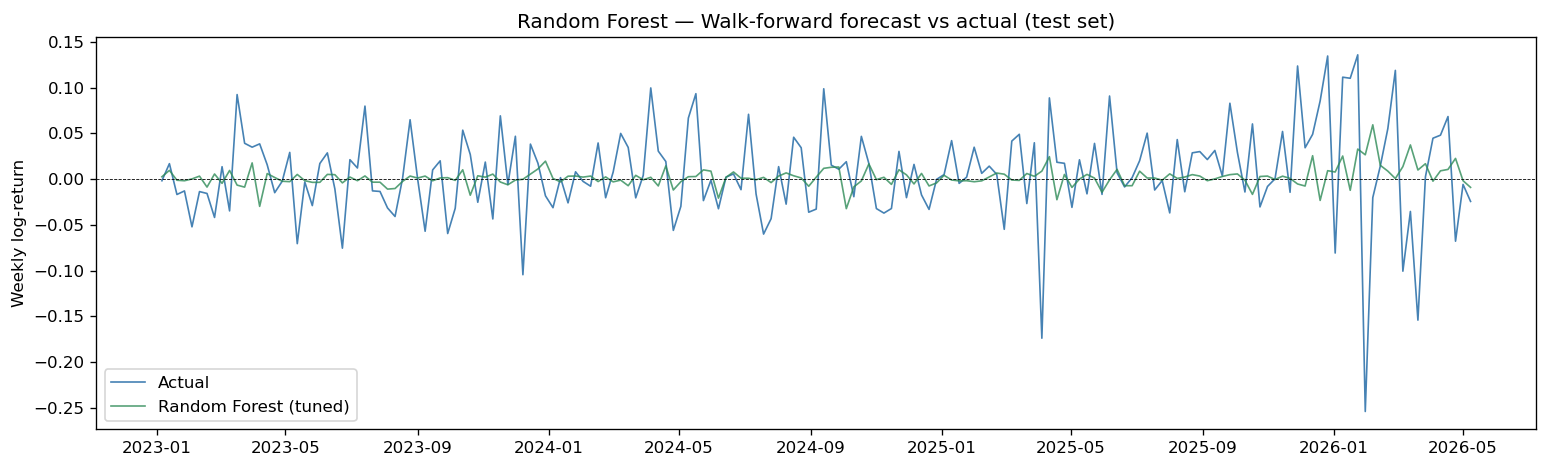

In [196]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_index, y_test,  lw=1, label='Actual',               color='steelblue')
ax.plot(test_index, preds_rf, lw=1, label='Random Forest (tuned)', color='seagreen', alpha=0.8)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.set_title('Random Forest — Walk-forward forecast vs actual (test set)')
ax.set_ylabel('Weekly log-return')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Feature importance

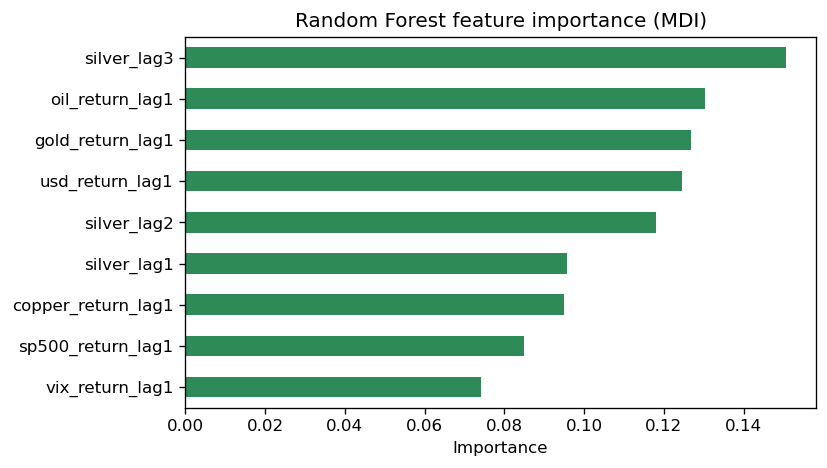

silver_lag3           0.150613
oil_return_lag1       0.130193
gold_return_lag1      0.126692
usd_return_lag1       0.124572
silver_lag2           0.117981
silver_lag1           0.095686
copper_return_lag1    0.095074
sp500_return_lag1     0.085016
vix_return_lag1       0.074172
dtype: float64


In [197]:
X_all = features_all[feature_cols].values
y_all = all_w[TARGET].values
mask  = ~np.isnan(X_all[:n_train]).any(axis=1)

final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
final_model.fit(X_all[:n_train][mask], y_all[:n_train][mask])

importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot.barh(ax=ax, color='seagreen')
ax.set_title('Random Forest feature importance (MDI)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## 8. Variants comparison

Re-runs the walk-forward Random Forest with different feature sets to test which
information sources improve out-of-sample performance.

`EXOG` = silver autocorrelation lags + 6 cross-asset lagged returns (gold, USD,
copper, S&P500, VIX, oil). `Tech` = silver lags + 4 tech indicators (no cross-assets).
A silver-lags-only model is omitted here because the AR information set is already
covered by the ARIMA baseline.

**Nonlinear features (NonLin).** Squared lagged returns — `silver_lag{k}²` for each
silver lag and `{exog}_lag1²` for each cross-asset. These capture **magnitude /
volatility** information independent of sign, motivated by ARCH-style volatility
clustering and the well-known leverage effect (large negative returns tend to be
followed by larger volatility). Trees can in principle approximate `x²` via
recursive splits, but each split has a cost in depth; explicit squared features
can help when the signal is weak relative to noise (as here). The `EXOG+NonLin`
variant lets the DM test directly answer whether volatility-style features add
predictive content beyond the linear EXOG base.

| Variant | Features |
|---|---|
| Tech | Silver lags + MACD line, MACD histogram, Bollinger bandwidth, 5-week silver vol |
| EXOG | Silver lags + 6 cross-asset returns (baseline) |
| EXOG+NonLin | EXOG + squared silver lags + squared cross-asset returns |
| EXOG+Tech | EXOG + tech indicators |
| EXOG+Reddit | EXOG + Reddit sentiment (lag 1) |
| EXOG+News | EXOG + GDELT news sentiment (lag 1) |
| EXOG+Reddit+News | EXOG + Reddit + news sentiment |
| EXOG+Tech+Sentiment | EXOG + tech + Reddit + news sentiment |

Each variant re-tunes hyperparameters on its own feature set before walk-forward
and is evaluated on DA and WDA against the EXOG baseline. The best variant
by WDA feeds the sub-period breakdown and the 2026 zoom plot below.

In [198]:
import os

sent_path = "../../data/processed/daily_sentiment.csv"
sentiment_available = os.path.exists(sent_path)
if sentiment_available:
    sentiment = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sentiment[["reddit_sentiment", "news_sentiment"]].resample("W-FRI").mean()
    sent_w_lag = sent_w.shift(1)
else:
    print("daily_sentiment.csv not found — sentiment variants will be skipped.")

TECH_COLS = ['macd_hist', 'macd_line', 'bb_bandwidth', 'silver_vol_5w']
SILVER_LAGS = [c for c in features_all.columns if c.startswith('silver_lag')]
ALL_BASE    = list(features_all.columns)  # silver lags + cross-asset return lags (no gs_z, no NonLin)

# ── Feature group: gs_ratio_z (level, lagged 1 week) ────────────────────────
GS_COLS = {}
for c in EXOG_LEVELS:
    if c in all_w.columns:
        GS_COLS[f'{c}_lag1'] = all_w[c].shift(1)

# ── Feature group: NonLin (squared lagged returns) ──────────────────────────
# Built from already-lagged columns in features_all — lookahead-safe by construction.
NONLIN_COLS = {}
for col in EXOG_RETURNS:
    lag_name = f'{col}_lag1'
    if lag_name in features_all.columns:
        NONLIN_COLS[f'{lag_name}_sq'] = features_all[lag_name] ** 2
for sl in SILVER_LAGS:
    NONLIN_COLS[f'{sl}_sq'] = features_all[sl] ** 2

# Sentiment helpers (Reddit + News, both lagged 1 week)
if sentiment_available:
    SENT_COLS = {
        "reddit_sentiment_lag1": sent_w_lag["reddit_sentiment"],
        "news_sentiment_lag1":   sent_w_lag["news_sentiment"],
    }
    REDDIT_COLS = {"reddit_sentiment_lag1": sent_w_lag["reddit_sentiment"]}
    NEWS_COLS   = {"news_sentiment_lag1":   sent_w_lag["news_sentiment"]}

tech_dict = {col: all_w[col] for col in TECH_COLS if col in all_w.columns}
all_candidates = {}

def tune(X_tr_s, y_tr_s):
    mask_s = ~np.isnan(X_tr_s).any(axis=1)
    X_tr_s, y_tr_s = X_tr_s[mask_s], y_tr_s[mask_s]
    best_rmse_s, best_params_s = np.inf, {}
    for combo in combos:
        params = dict(zip(keys, combo))
        fold_rmses = []
        for fold_tr, fold_val in tscv.split(X_tr_s):
            m = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
            m.fit(X_tr_s[fold_tr], y_tr_s[fold_tr])
            preds = m.predict(X_tr_s[fold_val])
            fold_rmses.append(np.sqrt(mean_squared_error(y_tr_s[fold_val], preds)))
        rmse = np.mean(fold_rmses)
        if rmse < best_rmse_s:
            best_rmse_s, best_params_s = rmse, params
    return best_params_s

def run_variant(label, base_cols, extra_cols=None):
    """base_cols: subset of features_all to include. extra_cols: dict of extra Series to add."""
    feats = features_all[list(base_cols)].copy()
    if extra_cols:
        for col_name, series in extra_cols.items():
            feats[col_name] = series.reindex(feats.index).ffill()
    fcols = feats.columns.tolist()
    X_tr_s = feats.iloc[:n_train][fcols].values
    y_tr_s = all_w[TARGET].iloc[:n_train].values
    params_s = tune(X_tr_s, y_tr_s)
    p_exp = walk_forward(all_w, feats, n_train, fcols,            **params_s)
    p_rol = walk_forward(all_w, feats, n_train, fcols, window=100, **params_s)
    print(f"--- {label} ---")
    evaluate(f"{label} expanding",      y_test, p_exp)
    evaluate(f"{label} rolling (100w)", y_test, p_rol)
    all_candidates[f"{label} expanding"]      = p_exp
    all_candidates[f"{label} rolling (100w)"] = p_rol

# ── Variant ladder ───────────────────────────────────────────────────────────
# Baseline: EXOG = silver lags + cross-asset return lags (no gs_z, no NonLin).
# Ablations test each feature group on top: GS, NonLin, Tech, Sentiment, ALL.

print("Tuning and running: Tech...")
run_variant("Tech", SILVER_LAGS, tech_dict)
print()

# EXOG baseline (returns-only) — already computed in §4
print("--- EXOG (baseline) ---")
evaluate("EXOG expanding",      y_test, preds_rf_exp)
evaluate("EXOG rolling (100w)", y_test, preds_rf_rol)
all_candidates["EXOG expanding"]      = preds_rf_exp
all_candidates["EXOG rolling (100w)"] = preds_rf_rol
print()

if GS_COLS:
    print("Tuning and running: EXOG+GS...")
    run_variant("EXOG+GS", ALL_BASE, GS_COLS)
    print()

print("Tuning and running: EXOG+NonLin...")
run_variant("EXOG+NonLin", ALL_BASE, NONLIN_COLS)
print()

print("Tuning and running: EXOG+Tech...")
run_variant("EXOG+Tech", ALL_BASE, tech_dict)
print()

if sentiment_available:
    print("Tuning and running: EXOG+Reddit+News...")
    run_variant("EXOG+Reddit+News", ALL_BASE, SENT_COLS)
    print()
    print("Tuning and running: EXOG+Reddit...")
    run_variant("EXOG+Reddit", ALL_BASE, REDDIT_COLS)
    print()
    print("Tuning and running: EXOG+News...")
    run_variant("EXOG+News", ALL_BASE, NEWS_COLS)
    print()
    if GS_COLS:
        print("Tuning and running: EXOG+GS+Sentiment...")
        run_variant("EXOG+GS+Sentiment", ALL_BASE, {**GS_COLS, **SENT_COLS})
        print()
    print("Tuning and running: EXOG+NonLin+Sentiment...")
    run_variant("EXOG+NonLin+Sentiment", ALL_BASE, {**NONLIN_COLS, **SENT_COLS})
    print()
    print("Tuning and running: EXOG+Tech+Sentiment...")
    run_variant("EXOG+Tech+Sentiment", ALL_BASE, {**tech_dict, **SENT_COLS})
    print()
    # Kitchen sink — gs_z + NonLin + Tech + Sentiment
    print("Tuning and running: EXOG+ALL...")
    run_variant("EXOG+ALL", ALL_BASE,
                {**(GS_COLS if GS_COLS else {}), **NONLIN_COLS, **tech_dict, **SENT_COLS})

Tuning and running: Tech...
--- Tech ---
Tech expanding                                 RMSE=0.05338  MAE=0.03793  DA=0.497  WDA=0.501
Tech rolling (100w)                            RMSE=0.05298  MAE=0.03740  DA=0.531  WDA=0.511

--- EXOG (baseline) ---
EXOG expanding                                 RMSE=0.05349  MAE=0.03754  DA=0.520  WDA=0.495
EXOG rolling (100w)                            RMSE=0.05335  MAE=0.03815  DA=0.486  WDA=0.475

Tuning and running: EXOG+GS...
--- EXOG+GS ---
EXOG+GS expanding                              RMSE=0.05173  MAE=0.03663  DA=0.537  WDA=0.514
EXOG+GS rolling (100w)                         RMSE=0.05203  MAE=0.03703  DA=0.526  WDA=0.500

Tuning and running: EXOG+NonLin...
--- EXOG+NonLin ---
EXOG+NonLin expanding                          RMSE=0.05276  MAE=0.03746  DA=0.509  WDA=0.476
EXOG+NonLin rolling (100w)                     RMSE=0.05383  MAE=0.03806  DA=0.514  WDA=0.543

Tuning and running: EXOG+Tech...
--- EXOG+Tech ---
EXOG+Tech expanding       

## Sub-period robustness: DA and WDA by year

Breaks down the best-performing variant by calendar year to check whether
the result is stable across different market regimes.

In [ ]:
best_name = max(all_candidates, key=lambda k:
    np.nansum(np.abs(y_test) * (np.sign(y_test) == np.sign(all_candidates[k]))) /
    np.nansum(np.abs(y_test)))
best_pred = all_candidates[best_name]
print("Best variant by WDA:", best_name)
res = period_metrics(y_test, best_pred, test_index, PERIODS)
display(res[["n", "DA", "WDA"]].style
        .format({"n": "{:.0f}", "DA": "{:.3f}", "WDA": "{:.3f}"})
        .background_gradient(cmap="RdYlGn", subset=["DA", "WDA"], vmin=0.4, vmax=0.7))

res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_rf_weekly.csv')

# Save winning variant predictions for cross-model DM tests in evaluation.ipynb
pd.DataFrame({'actual': y_test, 'predicted': best_pred}, index=test_index)\
  .rename_axis('Date').to_csv('../../data/processed/preds_rf_best_weekly.csv')
print(f'Saved winning-variant predictions: preds_rf_best_weekly.csv  ({best_name})')

## Diebold-Mariano test

Tests whether each variant produces statistically significant forecast improvements
over the EXOG baseline. H0: equal predictive accuracy (squared error loss).
p < 0.05 = significant improvement.

In [200]:
print("Diebold-Mariano tests — each variant vs EXOG baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = "EXOG expanding"
baseline_pred = all_candidates[baseline_key]
for name, pred in all_candidates.items():
    if name == baseline_key:
        continue
    diebold_mariano(y_test, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
EXOG expanding                           vs Tech expanding                            DM=+0.136  p=0.891  (ns)
EXOG expanding                           vs Tech rolling (100w)                       DM=+0.817  p=0.414  (ns)
EXOG expanding                           vs EXOG rolling (100w)                       DM=+0.328  p=0.743  (ns)
EXOG expanding                           vs EXOG+GS expanding                         DM=+1.836  p=0.066  (ns)
EXOG expanding                           vs EXOG+GS rolling (100w)                    DM=+1.953  p=0.051  (ns)
EXOG expanding                           vs EXOG+NonLin expanding                     DM=+1.827  p=0.068  (ns)
EXOG expanding                           vs EXOG+NonLin rolling (100w)                DM=-0.783  p=0.4

## 2026 zoom — actual vs best model

Focuses on the most recent out-of-sample period where silver has been most active.
Uses the best-performing variant selected earlier.

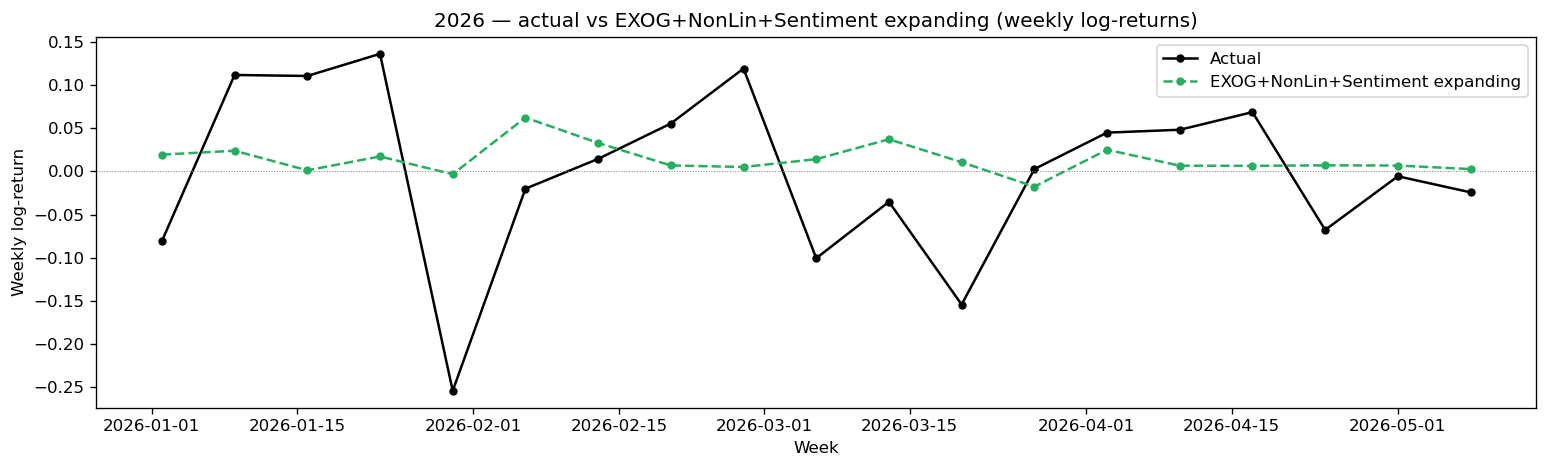

In [201]:
df26 = pd.DataFrame({"actual": y_test, "pred": best_pred}, index=test_index)
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#27ae60", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()